## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

## Create signals

In [4]:
freq = 1
ampl = 1
phi = 0

In [5]:
# datapoints
x = np.linspace(0, 50, 300)
#x = np.linspace(-np.pi, np.pi, 201)
y = ampl * np.sin(freq * x - phi)

In [6]:
# creat noise
np.random.seed(10)
noise = np.random.uniform(-0.3, 0.3, size = x.shape[0])
y_noisy = y + noise

## plot the clean and noisy signal

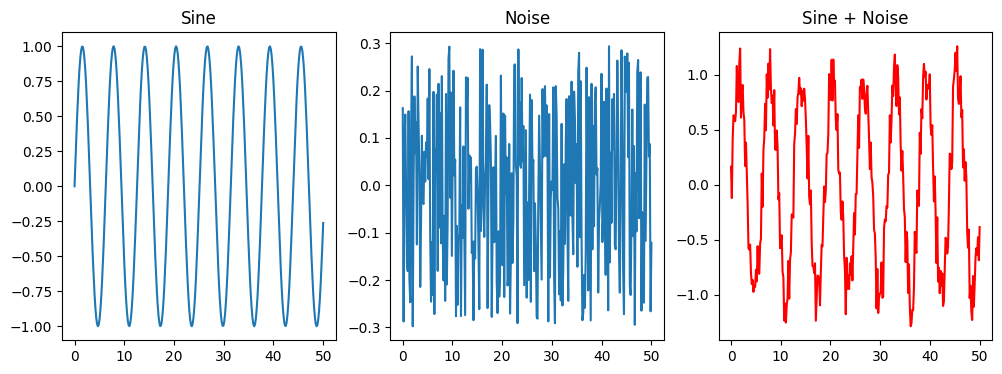

In [8]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
ax[0].set_title('Sine')
ax[0].plot(x, y)
ax[1].set_title('Noise')
ax[1].plot(x, noise)
ax[2].set_title('Sine + Noise')
ax[2].plot(x, y_noisy, 'r')

## create n_sample by sample_len, both clean and noisy

In [10]:

n_samples = 100
sample_len = 400

clean_sig = np.zeros((n_samples, sample_len))
noisy_sig = np.zeros((n_samples, sample_len))

for i in range (n_samples):  # i=0
    
    rand = np.random.uniform (0, 1)
    freq = 1+rand
    ampl = 1 + np.random.uniform (0, 1)
    #phi = 0 + np.random.uniform (0, 5)
    
    x = np.linspace(0, 50, sample_len)
    x = x + np.random.uniform (-10, 10)
    
    clean_sig [i, :] = ampl * np.sin(freq * x)
    noisy_sig [i, :] = clean_sig [i, :] + np.random.uniform (-0.4, 0.4, size=len(x))

## plot the clean and noisy signal

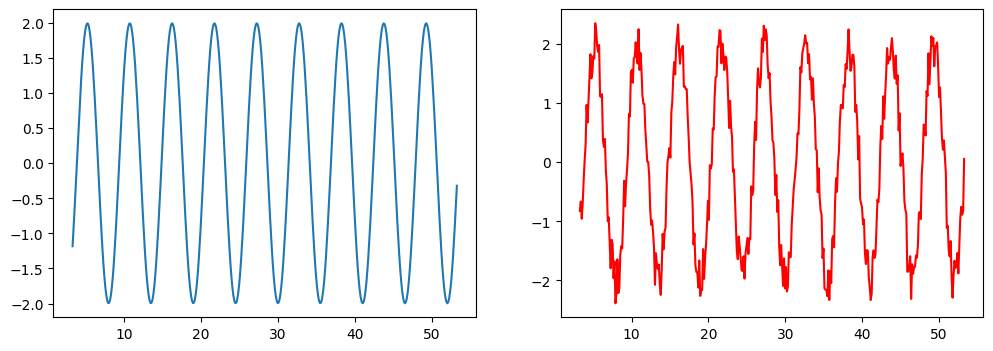

In [12]:
sample = 80
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
# ax[0].set_title('Sine')
ax[0].plot(x, clean_sig[sample, :])
ax[1].plot(x, noisy_sig[sample, :], 'r')

In [13]:
noisy_signals = noisy_sig.copy()
clean_signals = clean_sig.copy()

In [14]:
noisy_signals.shape

(100, 400)

## reshape (sample, length, featuers)

In [16]:

noisy_signals = noisy_signals.reshape(noisy_signals.shape[0],noisy_signals.shape[1],1)
clean_signals = clean_signals.reshape(clean_signals.shape[0],clean_signals.shape[1],1)

## Splitting the dataset into the Training set and Test set

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
#-- randomly assign the train and test set, useing sklearn
x_train, x_test, y_train, y_test = train_test_split(
    noisy_signals, clean_signals, test_size=0.15)

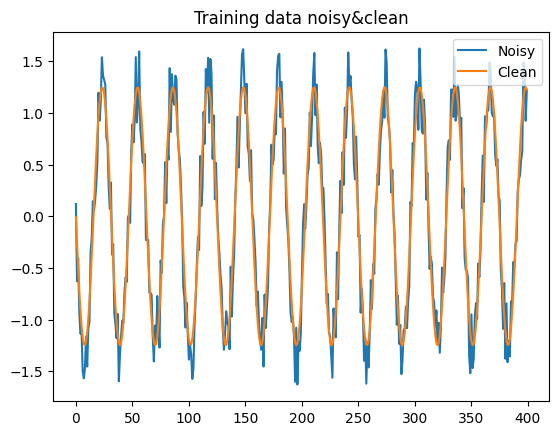

In [20]:
#-- Plot a sample signal
ind=2
fig, ax = plt.subplots()
plt.plot (x_test[ind,:], label="Noisy")
plt.plot (y_test[ind,:], label="Clean")
plt.title('Training data noisy&clean')
plt.legend()
plt.show()

## Importing the Keras libraries and packages

In [22]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU
from tensorflow.keras.layers import RepeatVector, TimeDistributed, Bidirectional

## define model

In [24]:
timesteps = x_train.shape[1]
No_of_features = x_train.shape[2]
No_epoch=10 
batch_size = 5

In [25]:

rnn_model = Sequential()
rnn_model.add(Bidirectional(GRU(units = 100, return_sequences = True,
                    activation='relu', input_shape = (timesteps, No_of_features))))

rnn_model.add(GRU(10, activation='relu', return_sequences=True))

#rnn_model.add(RepeatVector(timesteps))

rnn_model.add(GRU(10, activation='relu', return_sequences=True))
rnn_model.add(GRU(100, activation='relu', return_sequences=True))
rnn_model.add(TimeDistributed(Dense(1)))
#rnn_model.add(Dense(units = 1, activation='relu'))


C:\Users\wayne\anaconda3\envs\deeplearning-env\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
rnn_model.compile(optimizer='adam', loss='mean_absolute_error')

In [27]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
rnn_model.fit(x_train, y_train, epochs = No_epoch, 
              batch_size = batch_size)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 379ms/step - loss: 0.9222
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 386ms/step - loss: 0.5609
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step - loss: 0.1245
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 381ms/step - loss: 0.1011
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 395ms/step - loss: 0.0916
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 389ms/step - loss: 0.0876
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 389ms/step - loss: 0.0924
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 380ms/step - loss: 0.0820
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 377ms/step - loss: 0.0832
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 373ms/step - loss: 0.0789


## Predictions

In [30]:
#-- Predict the output for test set
x_test_pred = rnn_model.predict(x_test, verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [31]:
#-- save the RNN model to be used later----------------------------------------
from keras.models import load_model
model_name = "LSTM_Auto_sine.h5"
rnn_model.save(model_name)

In [32]:
#-- Load the model
rnn_model2 = load_model(model_name)

In [33]:
x_test_pred = rnn_model2.predict(x_test, verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


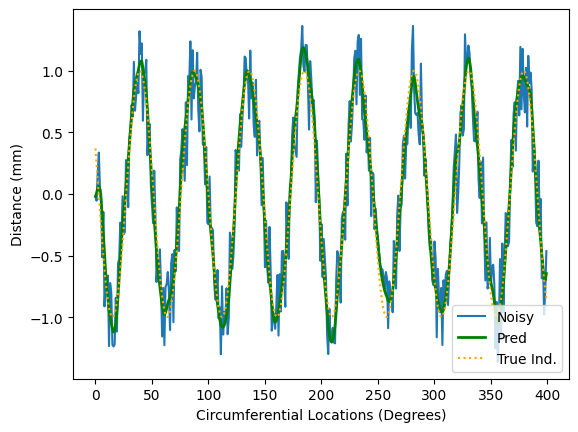

In [34]:
#-- plot the test results--------------
ind = 0
fig, ax = plt.subplots()

plt.plot (x_test[ind,:,0], label="Noisy")
plt.plot (x_test_pred[ind,:,0], color='g', linewidth=2,  label="Pred")
plt.plot (y_test[ind,], color = "orange", linestyle=':', linewidth=1.5,\
          label="True Ind.")

plt.legend()
plt.xlabel ("Circumferential Locations (Degrees)")
plt.ylabel ("Distance (mm)")
plt.show()

In [35]:
#plt.savefig("x_test"+str(ind)+".tif", dpi=200, format='tif')

## Are there any chances of improvement?

In [37]:
# define model
model = Sequential()
model.add(Bidirectional(LSTM(units = 128, return_sequences = True,
                    activation='tanh', input_shape = (timesteps, No_of_features))))

model.add(LSTM(64, activation='tanh', return_sequences=True))

model.add(LSTM(16, activation='tanh', return_sequences=True))

#model.add(RepeatVector(timesteps))

model.add(LSTM(16, activation='tanh', return_sequences=True))

model.add(LSTM(64, activation='tanh', return_sequences=True))

model.add(LSTM(128, activation='tanh', return_sequences=True))

model.add(TimeDistributed(Dense(1)))
#rnn_model.add(Dense(units = 1, activation='relu'))

In [38]:
model.compile(optimizer='adam', loss='mse')

In [39]:
model.fit(x_train, y_train, epochs = 100, 
              batch_size = 16, verbose=2)

Epoch 1/100
6/6 - 42s - 7s/step - loss: 1.0079
Epoch 2/100
6/6 - 5s - 844ms/step - loss: 0.4300
Epoch 3/100
6/6 - 5s - 845ms/step - loss: 0.2318
Epoch 4/100
6/6 - 5s - 830ms/step - loss: 0.1842
Epoch 5/100
6/6 - 5s - 878ms/step - loss: 0.1160
Epoch 6/100
6/6 - 5s - 863ms/step - loss: 0.1005
Epoch 7/100
6/6 - 5s - 858ms/step - loss: 0.0817
Epoch 8/100
6/6 - 5s - 855ms/step - loss: 0.0734
Epoch 9/100
6/6 - 5s - 855ms/step - loss: 0.0651
Epoch 10/100
6/6 - 5s - 820ms/step - loss: 0.0605
Epoch 11/100
6/6 - 5s - 836ms/step - loss: 0.0542
Epoch 12/100
6/6 - 5s - 831ms/step - loss: 0.0535
Epoch 13/100
6/6 - 5s - 829ms/step - loss: 0.0472
Epoch 14/100
6/6 - 5s - 826ms/step - loss: 0.0404
Epoch 15/100
6/6 - 5s - 848ms/step - loss: 0.0365
Epoch 16/100
6/6 - 5s - 827ms/step - loss: 0.0314
Epoch 17/100
6/6 - 5s - 816ms/step - loss: 0.0293
Epoch 18/100
6/6 - 5s - 806ms/step - loss: 0.0284
Epoch 19/100
6/6 - 5s - 840ms/step - loss: 0.0263
Epoch 20/100
6/6 - 5s - 825ms/step - loss: 0.0252
Epoch 21/10

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


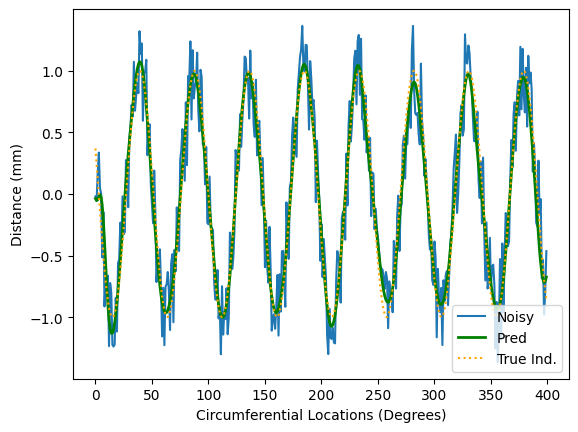

In [40]:
#-- Predict the output for test set
x_test_pred = model.predict(x_test, verbose=1)

#-- plot the test results--------------
ind = 0
fig, ax = plt.subplots()

plt.plot (x_test[ind,:,0], label="Noisy")
plt.plot (x_test_pred[ind,:,0], color='g', linewidth=2,  label="Pred")
plt.plot (y_test[ind,], color = "orange", linestyle=':', linewidth=1.5,\
          label="True Ind.")

plt.legend()
plt.xlabel ("Circumferential Locations (Degrees)")
plt.ylabel ("Distance (mm)")
plt.show()

In [41]:
model_name = "_LSTM_Auto_sine.h5"
model.save(model_name)